In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/single-oil-spill-image-delete-later/img_0953.png
/kaggle/input/single-oil-spill-image-delete-later/img_0872.jpg
/kaggle/input/single-oil-spill-image-delete-later/soc.png


In [8]:
import cv2

**Image 1 -> RGB of six of crows. processing**

In [9]:
img =  cv2.imread("/kaggle/input/single-oil-spill-image-delete-later/soc.png")

In [10]:
img.shape
#  so the img is 910x1224x3? 3 being rgb(actually BGR in cv2) channels ie (H,W,C)

(910, 1224, 3)

In [11]:
img.dtype

dtype('uint8')

In [12]:
print(np.amax(img))
print(np.amin(img))

255
0


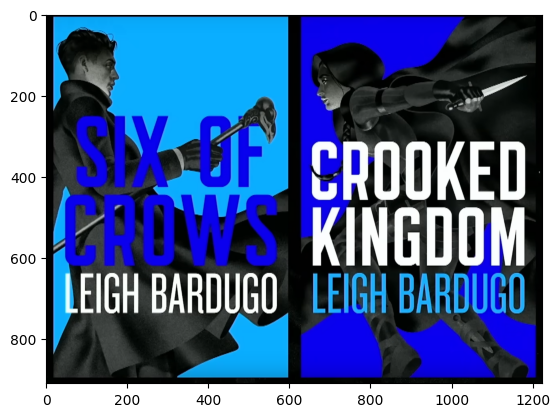

In [13]:
import matplotlib.pyplot as plt
plt.imshow(img)
# img looks like so because the cv2 loads the image as BGR instead of rgb, so blue is first...

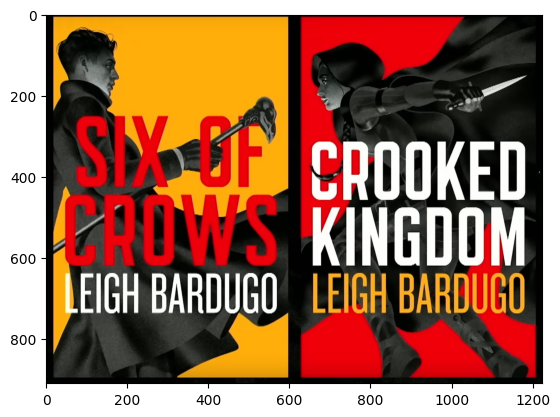

In [14]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [15]:
print(img.shape,img.dtype) 
print(img[50:55, 50:55,2])

(910, 1224, 3) uint8
[[12 12 12 12 28]
 [12 12 14 14 52]
 [12 12 14 14 53]
 [12 12 30 30 88]
 [12 13 30 30 38]]


(910, 1224)
[[179 179 179 179 181]
 [179 179 179 179 179]
 [179 179 179 179 180]
 [179 179 179 179 181]
 [179 180 179 179 131]]


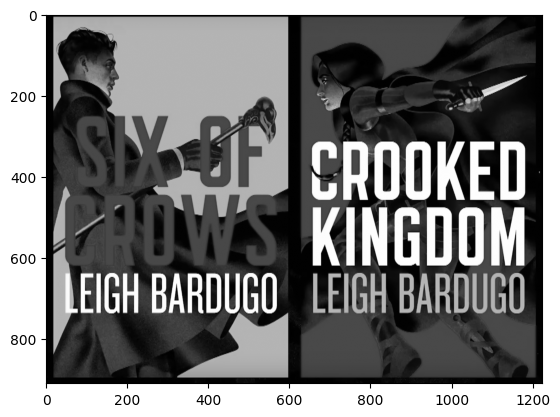

In [16]:
gray_image = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) #since we already converted to rgb

plt.imshow(gray_image, cmap='gray')

print(gray_image.shape)
# the channels are gone since only black and white each pixel with a value is being shown.
print(gray_image[50:55, 50:55])

**Image 2-> one oil spill sar image preprocessing**

(650, 1250, 3)
uint8


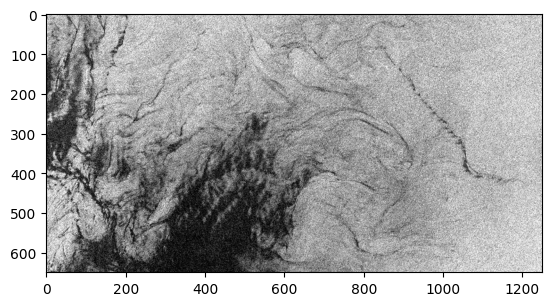

In [17]:
img2 = cv2.imread("/kaggle/input/single-oil-spill-image-delete-later/img_0872.jpg")
print(img2.shape)
print(img.dtype)
plt.imshow(img2,cmap='gray') # although gray this image has 3 channels


(650, 1250)


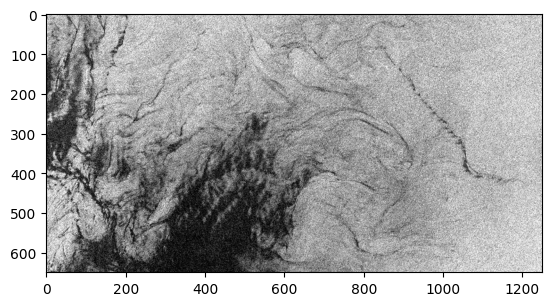

In [18]:
img2_gray=cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
plt.imshow(img2_gray, cmap='gray')
print(img2_gray.shape)

In [19]:
# to check if all 3 sar channels are same? if no remove them to 1
sar_im = img2
sar_im0= sar_im[...,0]
sar_im1= sar_im[...,1]
sar_im2= sar_im[...,2]

print(np.array_equal(sar_im0,sar_im1))
print(np.array_equal(sar_im1,sar_im2))

True
True


In [20]:
img2=img2[...,0] # since all the channels are same, why run the same thrice

**Comparing both images on grayscale**

In [21]:
# gray_image & img2
print(np.min(gray_image), np.max(gray_image), np.mean(gray_image), np.std(gray_image))
print(np.min(img2), np.max(img2), np.mean(img2), np.std(img2))

0 255 86.93295895281189 80.18751883427547
0 255 149.17838153846154 60.31878296335713


(array([7.53400e+03, 6.16910e+04, 3.58410e+04, 1.96800e+04, 1.03530e+04,
        8.85900e+03, 1.13110e+04, 1.08860e+04, 1.04560e+04, 9.89900e+03,
        9.72000e+03, 5.19400e+03, 7.92500e+03, 1.05250e+04, 1.01990e+04,
        9.56500e+03, 9.23700e+03, 8.27700e+03, 3.98700e+03, 6.46400e+03,
        7.79300e+03, 8.00700e+03, 7.71500e+03, 8.03500e+03, 8.22900e+03,
        3.93800e+03, 6.65200e+03, 7.65400e+03, 7.13900e+03, 6.75400e+03,
        6.64800e+03, 5.93700e+03, 2.92000e+03, 5.07100e+03, 5.63800e+03,
        5.64600e+03, 5.88800e+03, 5.88100e+03, 5.72200e+03, 3.54000e+03,
        6.44700e+03, 5.34600e+03, 6.56900e+03, 6.63200e+03, 6.75800e+03,
        6.67400e+03, 4.11000e+03, 7.68600e+03, 6.29600e+03, 7.53600e+03,
        7.45500e+03, 7.17700e+03, 6.96000e+03, 4.27400e+03, 7.47800e+03,
        6.21600e+03, 7.47200e+03, 7.66800e+03, 7.32700e+03, 8.08800e+03,
        7.54400e+03, 5.49400e+03, 7.09900e+03, 7.43900e+03, 7.86600e+03,
        7.65500e+03, 7.29400e+03, 7.40200e+03, 7.66

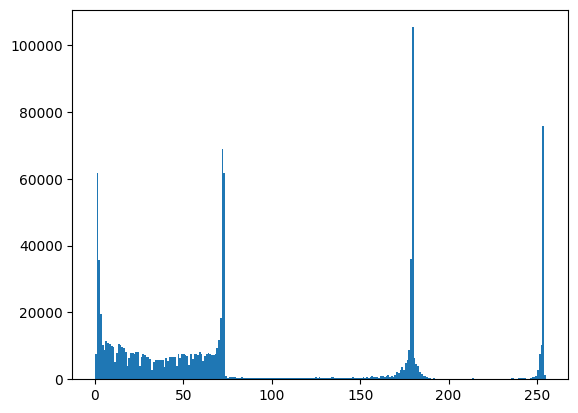

In [22]:
plt.hist(gray_image.flatten(), bins=256)


(array([ 9117.,  1016.,  1041.,  1036.,  1114.,  1143.,  1117.,  1218.,
         1147.,  1191.,  1171.,  1122.,  1236.,  1143.,  1129.,  1170.,
         1203.,  1094.,  1227.,  1196.,  1164.,  1210.,  1313.,  1285.,
         1232.,  1255.,  1325.,  1340.,  1289.,  1393.,  1353.,  1311.,
         1393.,  1397.,  1441.,  1438.,  1404.,  1405.,  1415.,  1405.,
         1431.,  1493.,  1547.,  1490.,  1559.,  1584.,  1456.,  1570.,
         1547.,  1543.,  1528.,  1649.,  1532.,  1545.,  1562.,  1492.,
         1553.,  1601.,  1527.,  1618.,  1599.,  1633.,  1580.,  1539.,
         1572.,  1596.,  1590.,  1645.,  1619.,  1683.,  1566.,  1608.,
         1695.,  1681.,  1643.,  1712.,  1705.,  1659.,  1697.,  1850.,
         1745.,  1744.,  1761.,  1836.,  1800.,  1860.,  1861.,  1930.,
         1910.,  1909.,  2048.,  2002.,  1954.,  2053.,  2154.,  2109.,
         2145.,  2160.,  2264.,  2283.,  2225.,  2323.,  2385.,  2394.,
         2398.,  2500.,  2609.,  2604.,  2626.,  2772.,  2729., 

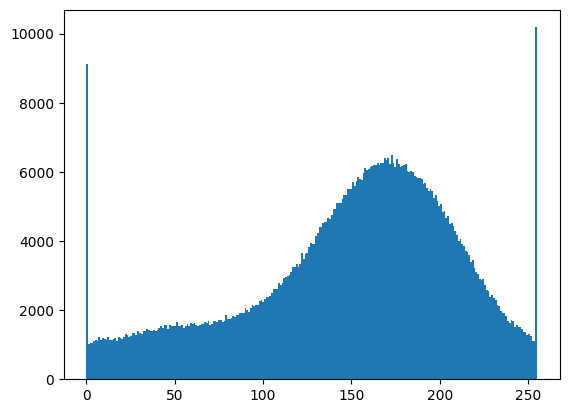

In [23]:
plt.hist(img2.flatten(), bins=256)

(array([ 9117.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
         1016.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,  1041.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
         1036.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,  1114.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,  1143.,     0.,     0.,     0.,     0.,     0.,
            0.,  1117.,     0.,     0.,     0.,     0.,     0.,     0.,
         1218.,     0.,     0.,     0.,     0.,  1147.,     0.,     0.,
            0.,     0.,  1191.,     0.,     0.,     0.,  1171., 

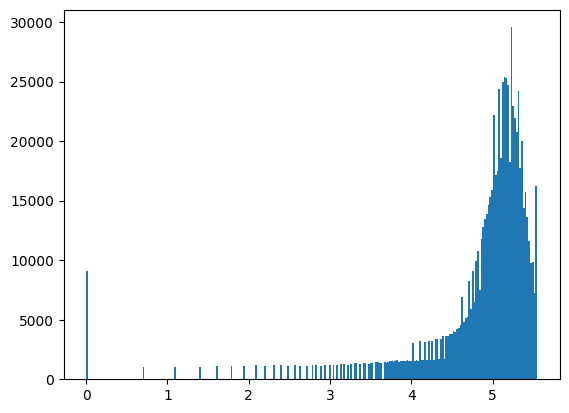

In [24]:
# a normal dist graph which indicated a lot of bright spots. since sar is back scatter vala. since the 
# intensity on brightspots can mislead us use LOG to normalize values.
sar_log = np.log1p(img2.astype(np.float32))
plt.hist(sar_log.flatten(), bins= 256)

#so the data is right skewed, now we will normalize it

****Data Normalisation****


SAR backscatter intensity operates on a root-power scale, and when plotted, SAR data typically exhibits a Gamma distribution. Taking the log-transform results in an almost Gaussian distribution, now measured in decibels (dB). This transformation is crucial because many machine learning and optimisation algorithms are designed to perform optimally with Normally-distributed data. Normalisation in this way ensures smoother training and better convergence in model training and algorithmic performance.

In [25]:
print(np.max(gray_image))
np.max(sar_log)

255


np.float32(5.5451775)

In [27]:
# i apologise to myself for the terrible naming convention.
sar_norm= sar_log /sar_log.max()

soc_norm= gray_image.astype(np.float32) / 255.0
print(soc_norm.shape, sar_norm.shape)



(910, 1224) (650, 1250)


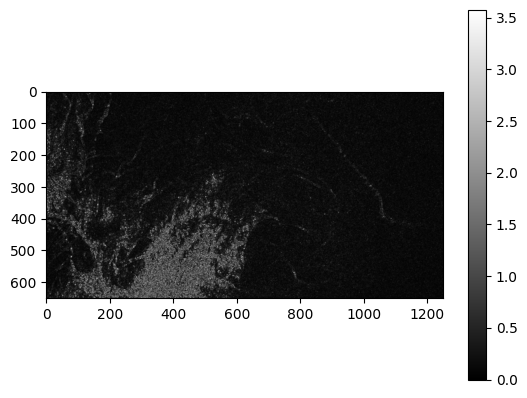

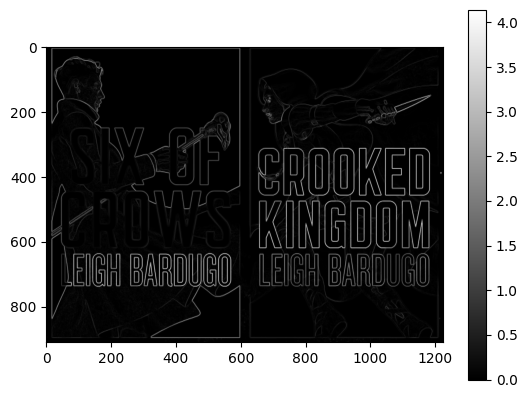

In [28]:
#histogram ignores where pixels are located. Spatial Theory, Histogram = intensity distribution only. It ignores spatial arrangement.
soc_gx = cv2.Sobel(soc_norm, cv2.CV_64F, 1, 0, ksize=3)
soc_gy = cv2.Sobel(soc_norm, cv2.CV_64F, 0, 1, ksize=3)

grad_mag_soc = np.sqrt(soc_gx**2 + soc_gy**2)
# sobel makes the edges strong and help understand spatial featues
oil_gx = cv2.Sobel(sar_norm, cv2.CV_64F, 1, 0, ksize=3)
oil_gy = cv2.Sobel(sar_norm, cv2.CV_64F, 0, 1, ksize=3)

grad_mag_oil = np.sqrt(oil_gx**2 + oil_gy**2)

plt.imshow(grad_mag_oil, cmap='gray')
plt.colorbar()
plt.show()

plt.imshow(grad_mag_soc, cmap='gray')
plt.colorbar()
plt.show()


(650, 1250, 3)


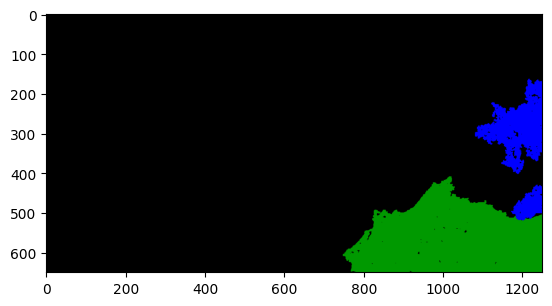

In [29]:
img3 = cv2.imread("/kaggle/input/single-oil-spill-image-delete-later/img_0953.png")
print(img3.shape)
img3.dtype
plt.imshow(img3)

In [30]:
mask_im = img3
mask0 = mask_im[...,0]
mask1 = mask_im[...,1]
mask2 = mask_im[...,2]

print(np.array_equal(mask0, mask1))
print(np.array_equal(mask2, mask1))
print(np.array_equal(mask0, mask2))

False
False
False
